# Desafio Final: Estatística Frequências e Medidas

**Atividade considerando a base de dados de enem_2023.json**

In [186]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [187]:
df = pd.read_json('enem_2023.json')
df.head()

,Linguagens,Ciências humanas,Ciências da natureza,Matemática,Redação,Sexo
0,585.669300,686.512178,390.482473,452.281333,546.371706,Homem
1,359.384608,642.084134,NaN,412.205207,741.825256,Mulher
2,622.732384,495.510719,443.183580,669.683401,684.515750,Homem
3,350.164605,602.041588,413.979810,676.608952,671.237114,Homem
4,384.093657,489.249140,609.758123,520.426698,744.375048,Homem


In [188]:
df.shape

(1000, 6)

## 1. Qual das disciplinas tem a maior amplitude de nota?

In [189]:
def maior_amplitude(df):
    colunas = df.columns[:-1]  # Ignora a última coluna "Sexo"
    amplitudes = {}
    
    for coluna in colunas:
        max_nota = df[coluna].max()
        min_nota = df[coluna].min()
        amplitudes[coluna] = max_nota - min_nota  # Cálculo direto da amplitude
    maior_disciplina = max(amplitudes)
    
    return maior_disciplina, amplitudes[maior_disciplina]

disciplina, valor_amplitude = maior_amplitude(df)
print(f'A disciplina com maior amplitude é {disciplina}, com uma amplitude de {valor_amplitude:.2f}')

A disciplina com maior amplitude é Redação, com uma amplitude de 729.16


## 2. Qual é a média e a mediana para cada uma das disciplinas? (Lembre-se de remover todos os valores nulos quando considerar a mediana)

In [190]:
# df.dropna(inplace = True)
# df.isna().sum()

# De acordo com as instruções na monitoria, comentei essa parte que remove os nulos.

In [191]:
colunas = df.columns[:-1]  # disciplinas

media = df[colunas].mean()
mediana = df[colunas].median()

df_media_mediana = pd.DataFrame({'Média': media, 'Mediana': mediana})
df_media_mediana

,Média,Mediana
Linguagens,514.524809,515.045250
Ciências humanas,527.042281,524.519920
Ciências da natureza,499.315583,500.479263
Matemática,535.965660,533.247767
Redação,637.783532,635.273973


## 3. Considerando o curso de Ciência da Computação da UFPE, onde o peso cada uma das disciplinas ponderado:

a. Redação - 2

b. Matemática e suas Tecnologias - 4

c. Linguagens, Códigos e suas Tecnologias - 2

d. Ciências Humanas e suas Tecnologias - 1

e. Ciências da Natureza e suas Tecnologias - 1

Qual o desvio padrão e média das notas dos 500 estudantes mais bem
colocados considerando esses pesos?

In [192]:
disciplinas = df[colunas]
pesos = {
    'Redação': 2,
    'Matemática': 4,
    'Linguagens': 2,
    'Ciências humanas': 1,
    'Ciências da natureza': 1}

# Função para calcular nota ponderada
def nota_ponderada(linha):
    total_peso = sum(pesos.values())
    
    soma_pesos_notas = 0
    for disciplina, peso in pesos.items():
        nota = linha[disciplina]
        soma_pesos_notas += nota * peso
    
    nota_ponderada = soma_pesos_notas / total_peso
    return nota_ponderada
disciplinas['Nota Ponderada'] = df.apply(nota_ponderada, axis=1)

In [193]:
disciplinas.head(3)

,Linguagens,Ciências humanas,Ciências da natureza,Matemática,Redação,Nota Ponderada
0,585.669300,686.512178,390.482473,452.281333,546.371706,515.020199
1,359.384608,642.084134,NaN,412.205207,741.825256,NaN
2,622.732384,495.510719,443.183580,669.683401,684.515750,623.192417


In [194]:
melhores_colocados = disciplinas.sort_values('Nota Ponderada', ascending = False).head(500)
melhores_colocados.head(3)

,Linguagens,Ciências humanas,Ciências da natureza,Matemática,Redação,Nota Ponderada
25,604.825455,447.532353,523.041011,727.181224,870.464077,682.987732
824,533.812379,611.760520,494.994598,807.877902,697.570213,680.103191
702,551.398112,637.818208,451.624683,803.769938,652.669636,671.265814


In [195]:
desvio_padrao = melhores_colocados['Nota Ponderada'].std().round()
media_500 = melhores_colocados['Nota Ponderada'].mean().round()

print(f'Sobre a nota ponderada - o desvio padrão é: {desvio_padrao} e a média é: {media_500}')

Sobre a nota ponderada - o desvio padrão é: 40.0 e a média é: 557.0


## 4. Se todos esses estudantes aplicassem para ciência da computação e existem apenas 40 vagas, qual seria a variância e média da nota dos estudantes que entraram no curso de ciência da computação?

In [196]:
vagas = melhores_colocados.head(40)

variancia = vagas['Nota Ponderada'].var().round()
media_40 = vagas['Nota Ponderada'].mean().round()

print(f'A variância da nota ponderada é: {variancia} e a média é: {media_40}')

A variância da nota ponderada é: 296.0 e a média é: 637.0


## 5. Qual o valor do teto do terceiro quartil para as disciplinas de matemática e linguagens?

In [197]:
df.describe()

,Linguagens,Ciências humanas,Ciências da natureza,Matemática,Redação
count,897.000000,936.000000,824.000000,924.000000,860.000000
mean,514.524809,527.042281,499.315583,535.965660,637.783532
std,84.009313,77.811519,78.760404,86.648100,115.339972
min,287.000000,289.900000,314.400000,319.800000,270.839965
25%,458.360558,475.424546,444.709076,479.172971,556.468366
50%,515.045250,524.519920,500.479263,533.247767,635.273973
75%,571.635876,581.401952,548.751678,592.912963,715.989868
max,804.456317,763.919695,802.004568,807.877902,1000.000000


In [198]:
# terceiro quartil arrendodado para cima

q3_matematica = np.ceil(df['Matemática'].quantile(0.75))
q3_linguagens = np.ceil(df['Linguagens'].quantile(0.75))

print(f'Teto do terceiro quartil de matemática e linguagens respectivamente: {q3_matematica} e {q3_linguagens}')

Teto do terceiro quartil de matemática e linguagens respectivamente: 593.0 e 572.0


## 6. Faça o histograma de Redação e Linguagens, de 20 em 20 pontos. Podemos dizer que são histogramas simétricos, justifique e classifique se não assimétricas?

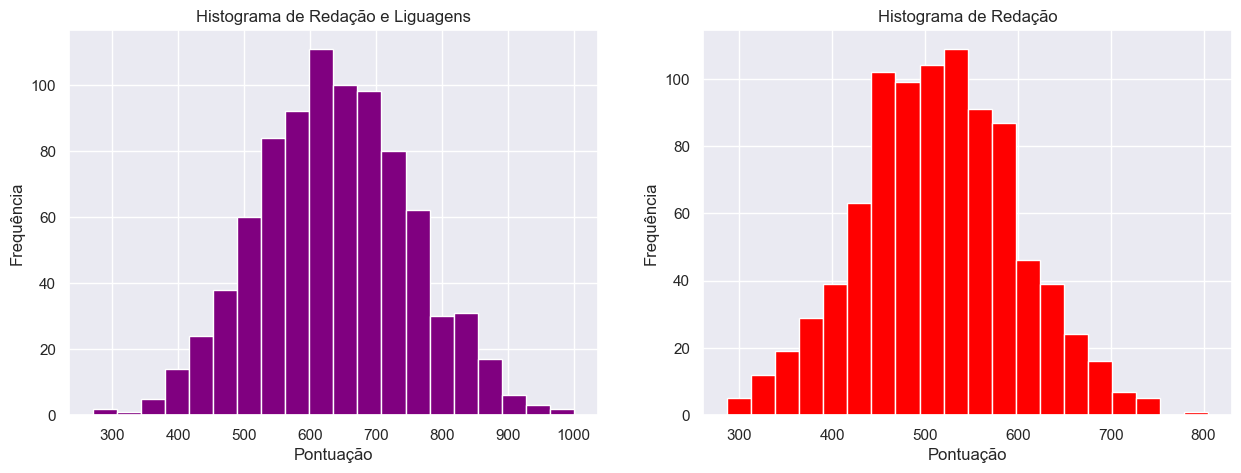

In [199]:
plt.figure(figsize=(15, 5))

# Histograma para Redação
plt.subplot(1, 2, 1)
plt.hist(df['Redação'], bins = 20, color = 'purple')
plt.title('Histograma de Redação e Liguagens')
plt.xlabel('Pontuação')
plt.ylabel('Frequência')

# Histograma para Linguagens
plt.subplot(1, 2, 2)
plt.hist(df['Linguagens'], bins=20, color='red')
plt.title('Histograma de Redação')
plt.xlabel('Pontuação')
plt.ylabel('Frequência')

plt.show()

**É simétrico pois concentra a maior parte dos dados no centro.**

## 7. Agora coloque um range fixo de 0 até 1000, você ainda tem a mesma opinião quanto a simetria?
`[plt.hist(dado, bins=_, range=[0, 1000])`

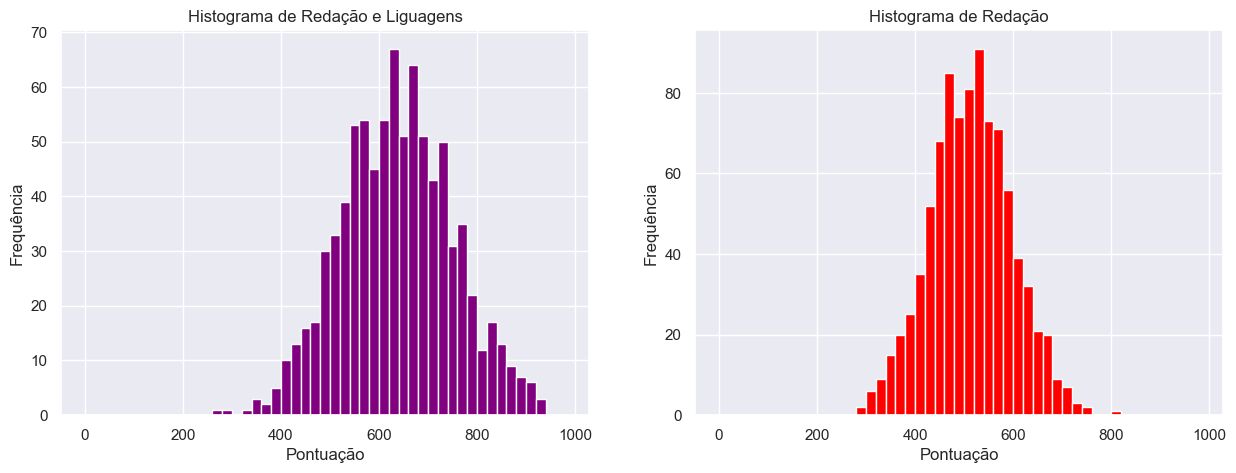

In [200]:
bins = range(0, 1000, 20)

plt.figure(figsize=(15, 5))

# Histograma para Redação
plt.subplot(1, 2, 1)
plt.hist(df['Redação'], bins = bins, color = 'purple')
plt.title('Histograma de Redação e Liguagens')
plt.xlabel('Pontuação')
plt.ylabel('Frequência')

# Histograma para Linguagens
plt.subplot(1, 2, 2)
plt.hist(df['Linguagens'], bins = bins, color='red')
plt.title('Histograma de Redação')
plt.xlabel('Pontuação')
plt.ylabel('Frequência')

plt.show()

**A aparência é um pouco diferente mas contuna parecidos com os plot anteriores, dados mais ao centro.**

## 8. Faça um boxplot do quartil de todas as disciplinas de ciências da natureza e redação. É possível enxergar outliers? Utilize o método IQR.

In [201]:
def find_outlier_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # Identifica outliers
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    
    return lower, upper, outliers

# Aplicar a função e imprime resultados
for column in df.select_dtypes(include = np.number).columns: # só as numéricas
    limite_inferior, limite_superior, out = find_outlier_iqr(df, column)
    
    # Imprime o nome da coluna e os limites dos outliers
    print(f"Disciplina: {column}")
    print(f"Margem Inferior: {limite_inferior:.2f}")
    print(f"Margem Superior: {limite_superior:.2f}")
    print(f"Número de Outliers: {len(out)}")
    print("-" * 40)

Disciplina: Linguagens
Margem Inferior: 288.45
Margem Superior: 741.55
Número de Outliers: 5
----------------------------------------
Disciplina: Ciências humanas
Margem Inferior: 316.46
Margem Superior: 740.37
Número de Outliers: 8
----------------------------------------
Disciplina: Ciências da natureza
Margem Inferior: 288.65
Margem Superior: 704.82
Número de Outliers: 3
----------------------------------------
Disciplina: Matemática
Margem Inferior: 308.56
Margem Superior: 763.52
Número de Outliers: 3
----------------------------------------
Disciplina: Redação
Margem Inferior: 317.19
Margem Superior: 955.27
Número de Outliers: 4
----------------------------------------


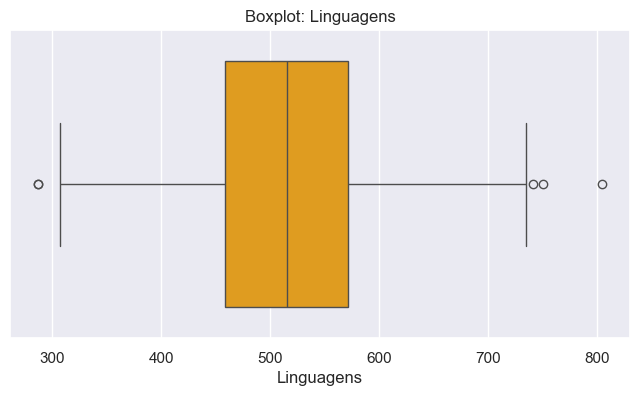

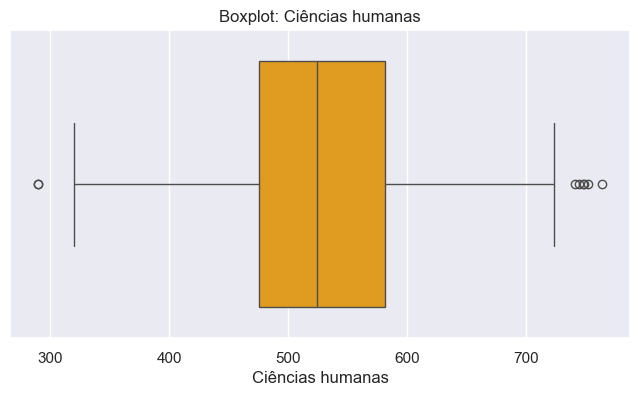

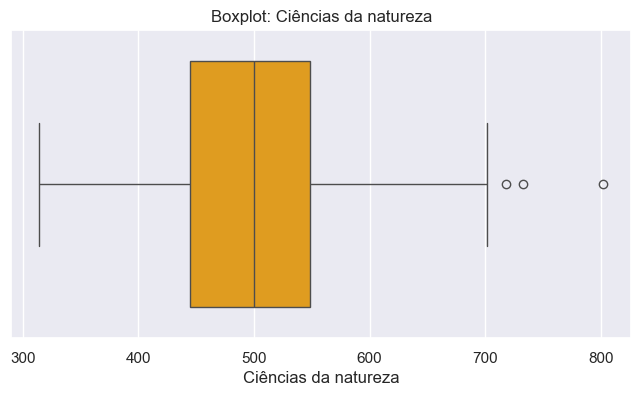

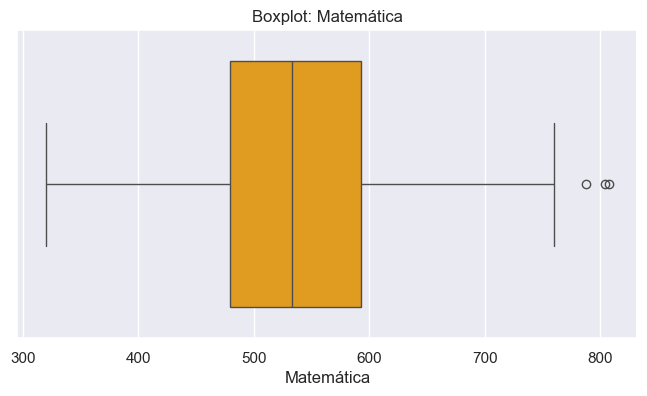

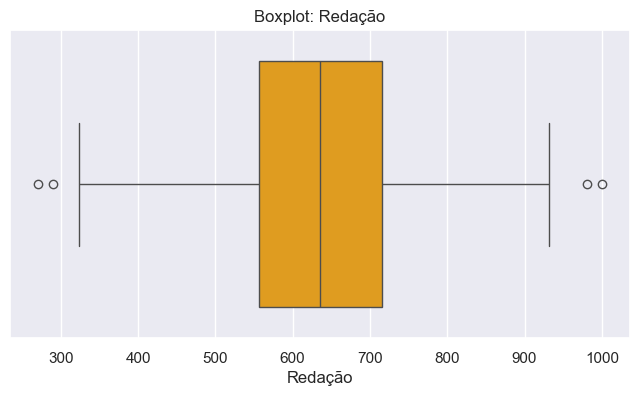

In [202]:
plt.rcParams['figure.figsize'] = [8, 4]
sns.set_theme()

for column in df.select_dtypes(include=np.number).columns: # filtrando o plot somente para variaveis numericas
    plt.figure()
    sns.boxplot(data = df , x = column, color='orange') #,showfliers=False)
    plt.title("Boxplot: "+ column)

## 9. Remova todos os outliers e verifique se eles são passíveis de alterar a média nacional significativamente? (considere significativamente um valor acima de 5%)

**Passos:**
1. Descobrir a média nacional
2. Remover os outliers
3. Verificar a nova média
4. Entender se vai +/- 5%

In [203]:
cols = df.columns[:-1]
df_9 = df[cols]
df_9['Média'] = df_9.mean(axis=1)
df_9.head()

,Linguagens,Ciências humanas,Ciências da natureza,Matemática,Redação,Média
0,585.669300,686.512178,390.482473,452.281333,546.371706,532.263398
1,359.384608,642.084134,NaN,412.205207,741.825256,538.874801
2,622.732384,495.510719,443.183580,669.683401,684.515750,583.125167
3,350.164605,602.041588,413.979810,676.608952,671.237114,542.806414
4,384.093657,489.249140,609.758123,520.426698,744.375048,549.580533


In [204]:
media_nacional_original = df_9['Média'].mean()

---

In [205]:
def remove_outliers(df):
    df_clean = df.copy()
    for column in df.select_dtypes(include=np.number).columns:  # Só as numéricas
        lower, upper, _ = find_outlier_iqr(df, column)  # Obtém as margens, ignora outliers
        df_clean = df_clean[(df_clean[column] >= lower) & (df_clean[column] <= upper)]
    
    return df_clean
df_sem_outliers = remove_outliers(df_9)

In [206]:
df_sem_outliers.shape

(536, 6)

In [207]:
media_sem_outliers = df_sem_outliers['Média'].mean()

---

In [208]:
variacao_per = ((media_sem_outliers - media_nacional_original)/media_nacional_original*100)
variacao_per

0.39873531420463215

**A variação percentual dos resultados é menor que 5%, logo não é significativa.**

## 10. Considerando valores nulos, tente encontrar qual seria a melhor medida de tendência que pode substituir as notas nulas. Média, moda ou mediana? Substitua o valor por todos os três e diga qual delas altera menos a média geral e o desvio padrão

In [209]:
def substituir_e_calcular_stats(df, coluna):
    
    # Calculando média e desvio padrão originais
    media_original = df[coluna].mean()
    desvio_padrao_original = df[coluna].std()
    
    # Substituindo NaNs pela média
    df_media = df.copy()
    media = df_media[coluna].mean()
    df_media[coluna].fillna(media, inplace=True)
    media_media = df_media[coluna].mean()
    desvio_padrao_media = df_media[coluna].std()
    
    # Substituindo NaNs pela moda
    df_moda = df.copy()
    moda = df_moda[coluna].mode()[0]
    df_moda[coluna].fillna(moda, inplace=True)
    media_moda = df_moda[coluna].mean()
    desvio_padrao_moda = df_moda[coluna].std()
    
    # Substituindo NaNs pela mediana
    df_mediana = df.copy()
    mediana = df_mediana[coluna].median()
    df_mediana[coluna].fillna(mediana, inplace=True)
    media_mediana = df_mediana[coluna].mean()
    desvio_padrao_mediana = df_mediana[coluna].std()
    
    # Criando o DataFrame com os resultados
    resultados = pd.DataFrame({
        'Medida': ['Média Original', 'Desvio Padrão Original', 
                   'Média Após Substituir por Média', 'Desvio Padrão Após Substituir por Média',
                   'Média Após Substituir por Moda', 'Desvio Padrão Após Substituir por Moda',
                   'Média Após Substituir por Mediana', 'Desvio Padrão Após Substituir por Mediana'],
        'Valor': [media_original, desvio_padrao_original,
                  media_media, desvio_padrao_media,
                  media_moda, desvio_padrao_moda,
                  media_mediana, desvio_padrao_mediana]
    })
    
    return resultados


substituir_e_calcular_stats(disciplinas, 'Nota Ponderada')

,Medida,Valor
0,Média Original,549.650405
1,Desvio Padrão Original,46.150440
2,Média Após Substituir por Média,549.650405
3,Desvio Padrão Após Substituir por Média,34.149690
4,Média Após Substituir por Moda,491.536515
5,Desvio Padrão Após Substituir por Moda,72.559015
6,Média Após Substituir por Mediana,548.763926
7,Desvio Padrão Após Substituir por Mediana,34.163651
